<a href="https://www.kaggle.com/code/syedfarazhussaini/playground-series-s5e4?scriptVersionId=237127826" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 🏆 Kaggle Playground Series - Season 5, Episode 4
## Predict Podcast Listening Time

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For enhanced plotting
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [3]:
#Ignore warnings from notebook
import warnings
warnings.simplefilter(action = "ignore", category = RuntimeWarning)

In [4]:
inputFiles = {}
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        inputFiles[filename.replace(".csv","")] = os.path.join(dirname, filename)

inputFiles

{'sample_submission': '/kaggle/input/playground-series-s5e4/sample_submission.csv',
 'train': '/kaggle/input/playground-series-s5e4/train.csv',
 'test': '/kaggle/input/playground-series-s5e4/test.csv'}

In [5]:
sample_submission_df = pd.read_csv(inputFiles['sample_submission'])
print(sample_submission_df.head())

       id  Listening_Time_minutes
0  750000                  45.437
1  750001                  45.437
2  750002                  45.437
3  750003                  45.437
4  750004                  45.437


In [6]:
train_df = pd.read_csv(inputFiles["train"])
print(train_df.head())

   id     Podcast_Name Episode_Title  Episode_Length_minutes       Genre  \
0   0  Mystery Matters    Episode 98                     NaN  True Crime   
1   1    Joke Junction    Episode 26                  119.80      Comedy   
2   2   Study Sessions    Episode 16                   73.90   Education   
3   3   Digital Digest    Episode 45                   67.17  Technology   
4   4      Mind & Body    Episode 86                  110.51      Health   

   Host_Popularity_percentage Publication_Day Publication_Time  \
0                       74.81        Thursday            Night   
1                       66.95        Saturday        Afternoon   
2                       69.97         Tuesday          Evening   
3                       57.22          Monday          Morning   
4                       80.07          Monday        Afternoon   

   Guest_Popularity_percentage  Number_of_Ads Episode_Sentiment  \
0                          NaN            0.0          Positive   
1           

In [7]:
test_df = pd.read_csv(inputFiles["test"])
print(test_df.head())

       id         Podcast_Name Episode_Title  Episode_Length_minutes  \
0  750000  Educational Nuggets    Episode 73                   78.96   
1  750001          Sound Waves    Episode 23                   27.87   
2  750002        Joke Junction    Episode 11                   69.10   
3  750003        Comedy Corner    Episode 73                  115.39   
4  750004         Life Lessons    Episode 50                   72.32   

       Genre  Host_Popularity_percentage Publication_Day Publication_Time  \
0  Education                       38.11        Saturday          Evening   
1      Music                       71.29          Sunday          Morning   
2     Comedy                       67.89          Friday          Evening   
3     Comedy                       23.40          Sunday          Morning   
4  Lifestyle                       58.10       Wednesday          Morning   

   Guest_Popularity_percentage  Number_of_Ads Episode_Sentiment  
0                        53.33        

In [8]:
# Print shapes to see number of rows/columns
print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("\nSample Submission Format:")
print(sample_submission_df.head())

Train data shape: (750000, 12)
Test data shape: (250000, 11)

Sample Submission Format:
       id  Listening_Time_minutes
0  750000                  45.437
1  750001                  45.437
2  750002                  45.437
3  750003                  45.437
4  750004                  45.437


In [9]:
# Train data info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [10]:
train_df.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [11]:
train_df.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

# Exploratory Data Analysis

## 1. Analyze the Target Variable (Listening_Time_minutes)
   
**Distribution**: How are the listening times distributed? Is it normal, skewed? Are there many people listening for very short or very long times?

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


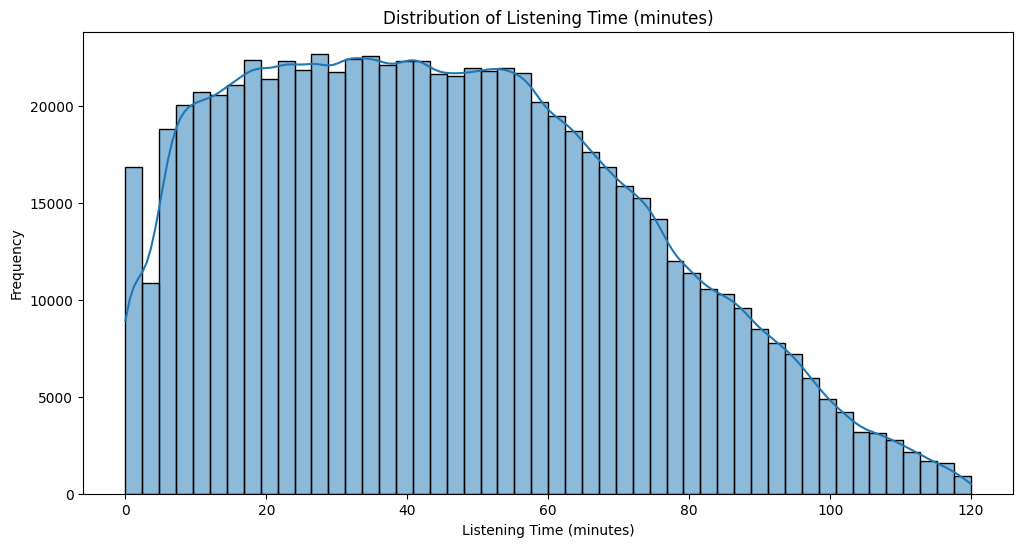

In [12]:
# Distribution of the target variable
plt.figure(figsize=(12, 6))
sns.histplot(train_df['Listening_Time_minutes'], kde=True, bins=50)
plt.title('Distribution of Listening Time (minutes)')
plt.xlabel('Listening Time (minutes)')
plt.ylabel('Frequency')
plt.show()

**Interpretation**: By Looking at the shape, it's roughly bell-shaped. The graph slight right skew, the tail extending towards longer listening times. Since this is not extreme, so it probably does not require transformation, like log, but it's good to observe. The peak seems closer to 40-50 minutes.

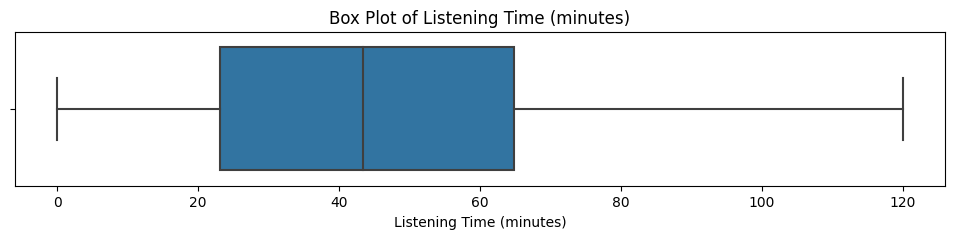

In [13]:
# Box plot for outliers
plt.figure(figsize=(12, 2))
sns.boxplot(x=train_df['Listening_Time_minutes'])
plt.title('Box Plot of Listening Time (minutes)')
plt.xlabel('Listening Time (minutes)')
plt.show()

**Interpretation**: Box plot shows mid-point is little over 40 minutes. The outlier start from initial recording to early 20m mintures before the listener leaves. And after mid 60 mintures mark and go the full 2 hours. This tells you about the typical listening behavior.

## 2. Analyze Numerical Features
- Look at the distributions of other numerical columns identified in .describe(): Episode_Length_minutes, Host_Popularity_percentage, Guest_Popularity_percentage, Number_of_Ads.
- Paying attention to the max values as seen in .describe(): Host_Popularity_percentage goes up to 119.46, Guest_Popularity_percentage to 119.91, Number_of_Ads to 103.91. Do percentages over 100 make sense? Is the max number of ads realistic or an outlier/error?

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


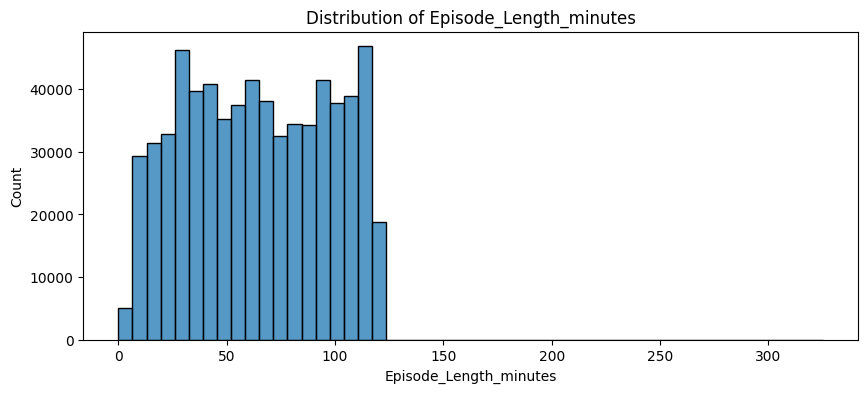

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


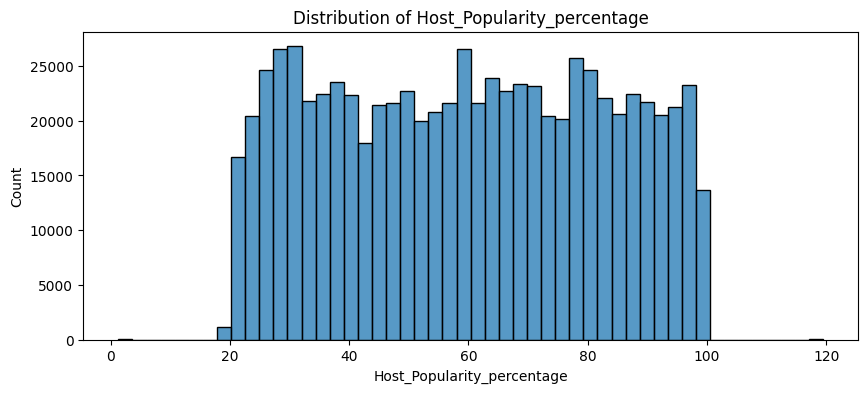

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


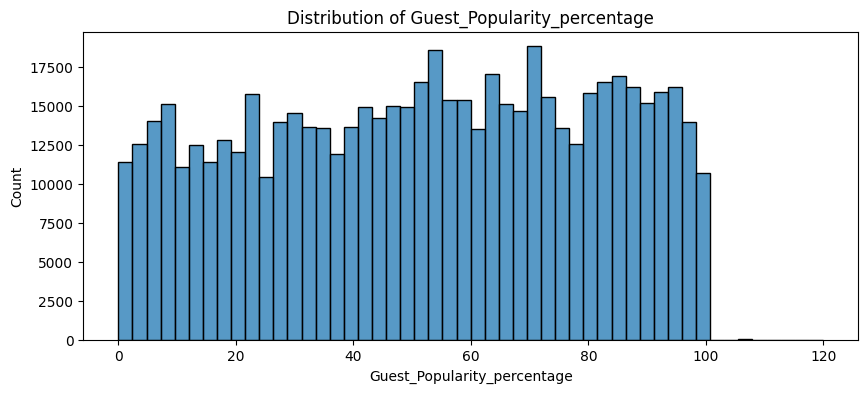

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


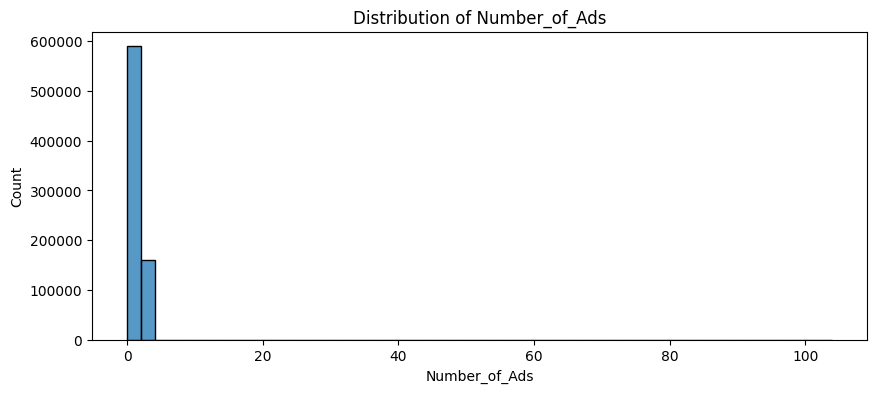


High values for Number_of_Ads:
283606    103.91
683147    103.88
537705    103.75
602553    103.25
672139    103.25
Name: Number_of_Ads, dtype: float64


In [14]:
numerical_cols = ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(train_df[col].dropna(), kde=False, bins=50) # Use dropna() for columns with missing values
    plt.title(f'Distribution of {col}')
    plt.show()
    # Optional: Add boxplots too if you suspect outliers
    # plt.figure(figsize=(10, 1))
    # sns.boxplot(x=train_df[col].dropna())
    # plt.title(f'Box Plot of {col}')
    # plt.show()

# Specifically investigate the Number_of_Ads outlier
print("\nHigh values for Number_of_Ads:")
print(train_df['Number_of_Ads'].sort_values(ascending=False).head())

**Interpretation**: 
* `Number_of_Ads > 100`, is this a typo or real yet extreme value? Are ads the same format? Does the 103 count mean few second short ad vs 3 ads that are minutes long used for breaktime. 
* `Popularity > 100`, Could this metric be relative, as in 110% means 10% above average, or is it bad data. It might be better to cap this value at 100.

## 3. Analyze Categorical Features
Examine the unique values and their frequencies for Genre, Publication_Day, Publication_Time, Episode_Sentiment.

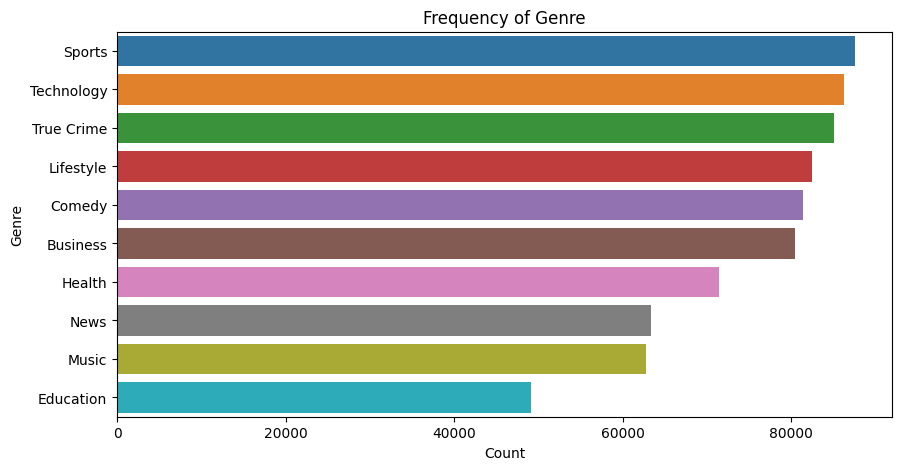


Value Counts for Genre:
Genre
Sports        87606
Technology    86256
True Crime    85059
Lifestyle     82461
Comedy        81453
Business      80521
Health        71416
News          63385
Music         62743
Education     49100
Name: count, dtype: int64
------------------------------


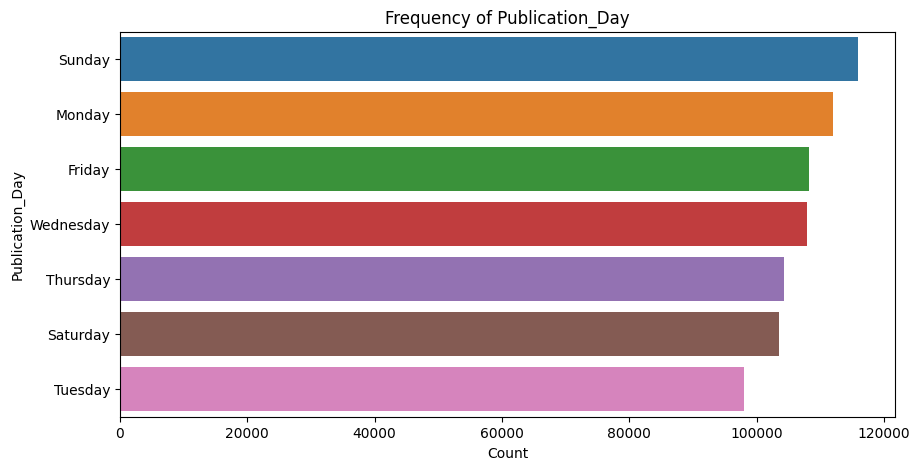


Value Counts for Publication_Day:
Publication_Day
Sunday       115946
Monday       111963
Friday       108237
Wednesday    107886
Thursday     104360
Saturday     103505
Tuesday       98103
Name: count, dtype: int64
------------------------------


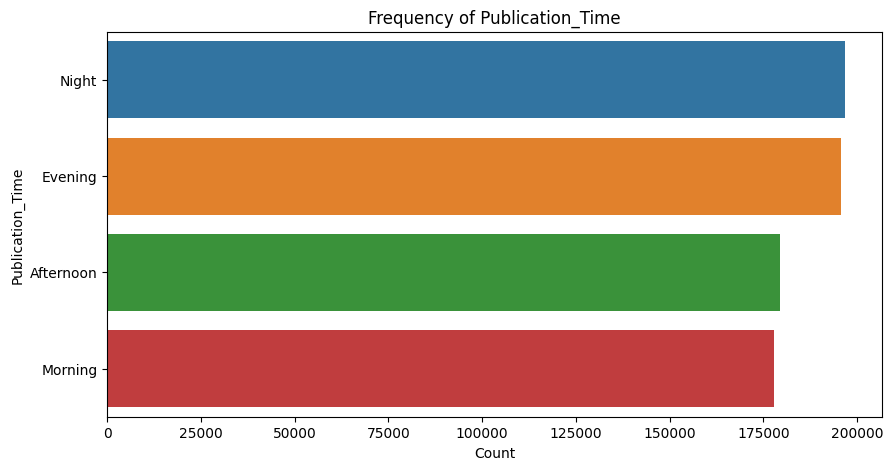


Value Counts for Publication_Time:
Publication_Time
Night        196849
Evening      195778
Afternoon    179460
Morning      177913
Name: count, dtype: int64
------------------------------


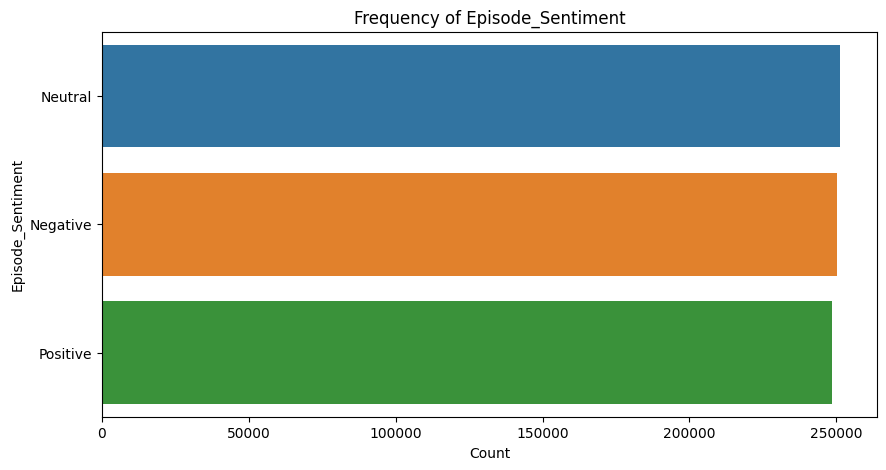


Value Counts for Episode_Sentiment:
Episode_Sentiment
Neutral     251291
Negative    250116
Positive    248593
Name: count, dtype: int64
------------------------------


In [15]:
categorical_cols = ['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=train_df[col], order = train_df[col].value_counts().index) # Order by frequency
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()
    print(f"\nValue Counts for {col}:")
    print(train_df[col].value_counts())
    print("-" * 30)

**Interpretation**: This helps understand the composition of the dataset. Categories ae fairly balanced, Education just fall short when compared to Sports which is nearly double. There are not rare categories. Sentiments are almost perfectly equal. The Podcast seem to be published throughout the day but seem have a preferance for night and evening. Probably aiming for around lunch time and after dinner. While prefering for Sundays and Monday, and relaxing on Tuesdays.

## 4. Explore Relationships with the Target Variable
Numerical vs. Target: How do numerical features correlate with Listening_Time_minutes?

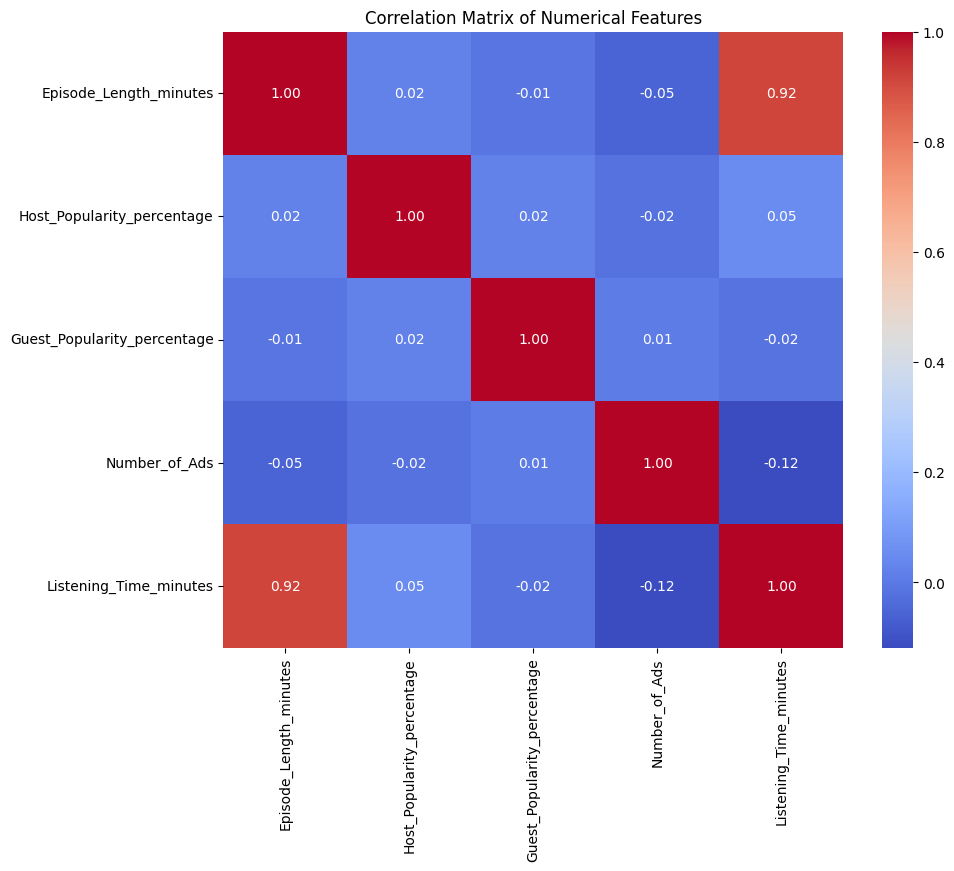

In [16]:
# Scatter plot (can be slow for large data, maybe sample first if needed)
# sns.pairplot(train_df, vars=numerical_cols + ['Listening_Time_minutes'])
# plt.show()

# Correlation Heatmap (more efficient)
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation, including the target
corr_cols = numerical_cols + ['Listening_Time_minutes']
correlation_matrix = train_df[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Categorical vs. Target**: Does the average listening time vary significantly across different categories?

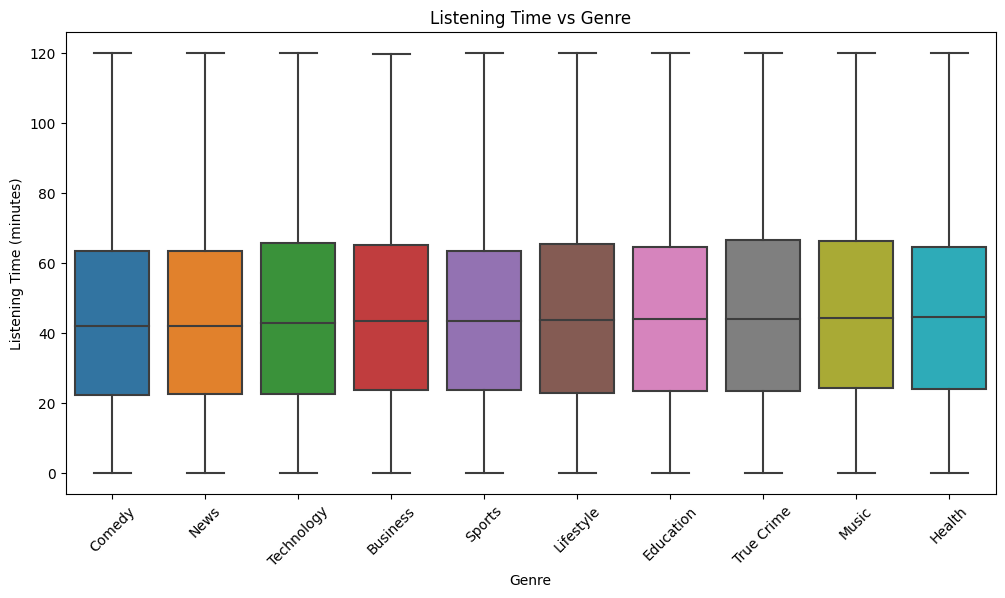

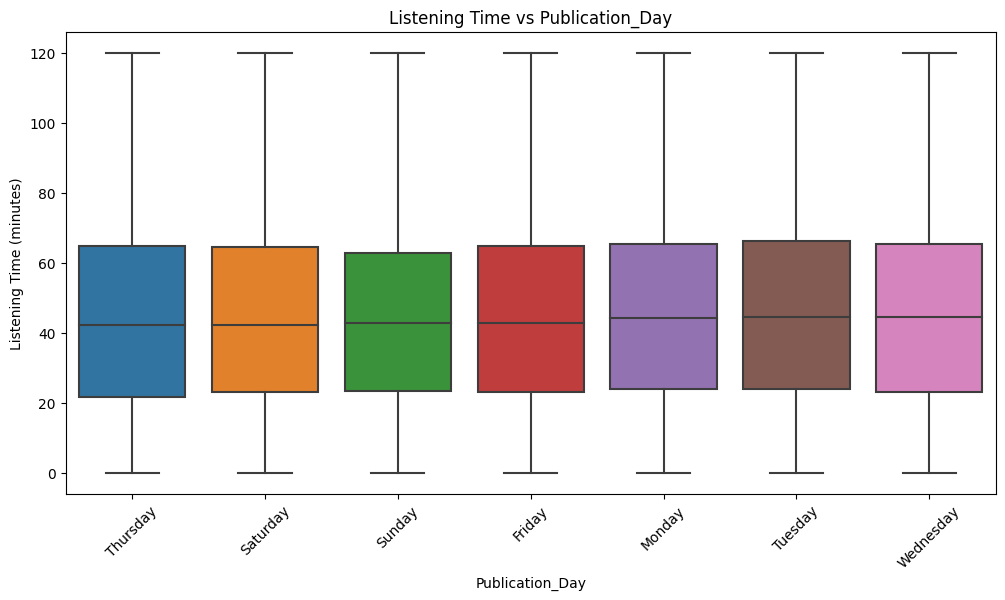

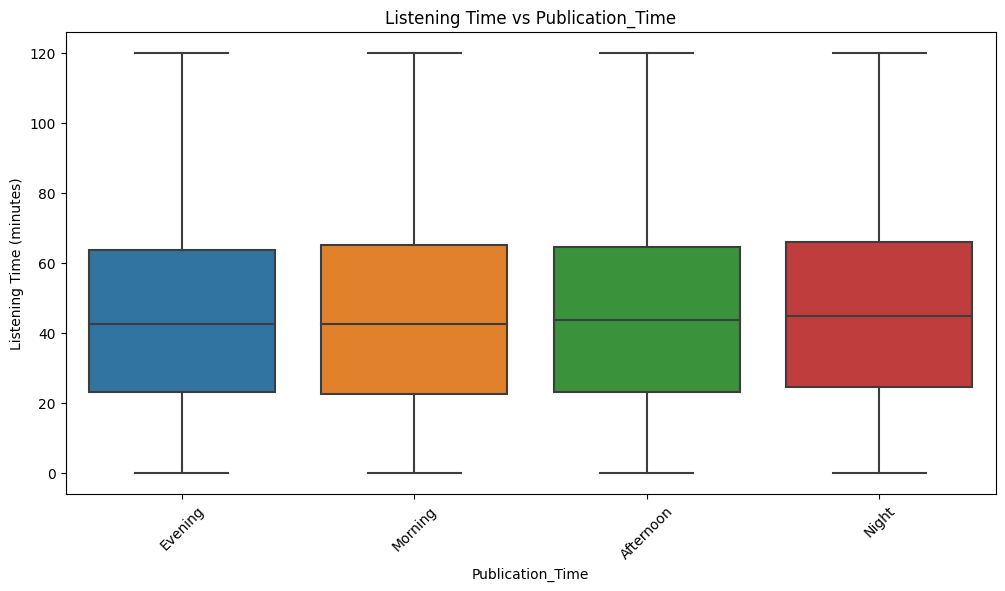

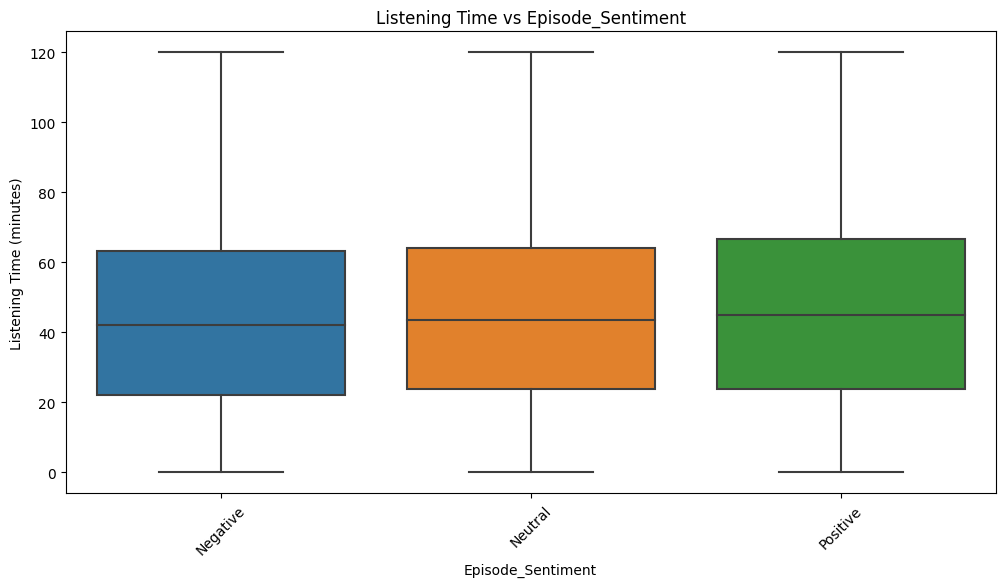

In [17]:
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=train_df[col], y=train_df['Listening_Time_minutes'], order=train_df.groupby(col)['Listening_Time_minutes'].median().sort_values().index) # Order by median listening time
    plt.title(f'Listening Time vs {col}')
    plt.xlabel(col)
    plt.ylabel('Listening Time (minutes)')
    plt.xticks(rotation=45)
    plt.show()

**Interpretation**: The correlation matrix shows linear relationships (positive values mean one tends to increase with the other, negative means the opposite). Box plots show if the distribution of listening times differs across categories. Look for features that seem to strongly influence listening time. Episode_Length_minutes is often a strong predictor.

## 5. Handle High-Cardinality Features (Initial Thoughts)
* Podcast_Name and Episode_Title likely have too many unique values to treat as simple categories. For now, just be aware of them. Later, you might:
  * Ignore them for a baseline model.
  * Extract features (like count/frequency encoding).
  * Use more advanced text processing (though maybe overkill for a playground competition).

## 6. Revisit Missing Values
* You know Episode_Length_minutes, Guest_Popularity_percentage, and Number_of_Ads (1 row) have missing values.
* How does the absence of a value relate to the target? (e.g., do episodes without guest popularity info have different listening times?)

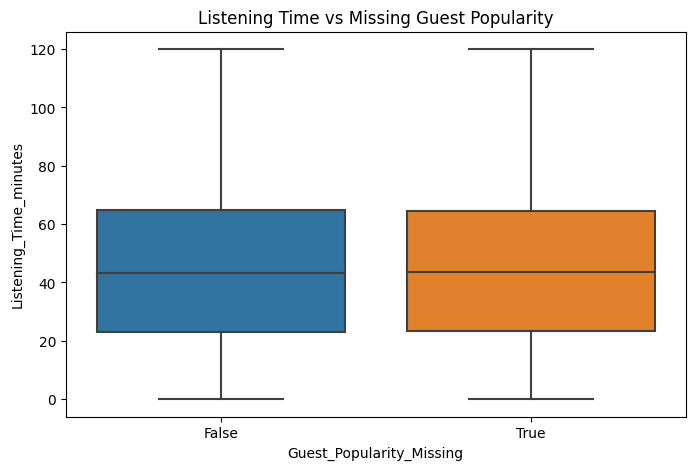

In [18]:
# Compare listening time for rows with/without missing Guest_Popularity_percentage
train_df['Guest_Popularity_Missing'] = train_df['Guest_Popularity_percentage'].isnull()
plt.figure(figsize=(8, 5))
sns.boxplot(x='Guest_Popularity_Missing', y='Listening_Time_minutes', data=train_df)
plt.title('Listening Time vs Missing Guest Popularity')
plt.show()
train_df.drop('Guest_Popularity_Missing', axis=1, inplace=True)

**Interpretation**: This helps inform how you might impute (fill in) these missing values later. If missingness seems related to the target, a simple mean/median might not be the best strategy. This strongly suggests that simply imputing with mean/medium might hide valuable information.

# Preprocessing
## 1. Combine Train and Test Data

In [19]:
# Store number of training rows
ntrain = train_df.shape[0]

# Separate target variable
target = train_df['Listening_Time_minutes']
train_ids = train_df['id']
test_ids = test_df['id']

# Drop target from train_df for now
train_df_features = train_df.drop(['id', 'Listening_Time_minutes'], axis=1)
test_df_features = test_df.drop('id', axis=1) # test_df doesn't have the target

# Combine for preprocessing
combined_df = pd.concat((train_df_features, test_df_features)).reset_index(drop=True)

print("Combined shape:", combined_df.shape)

Combined shape: (1000000, 10)


## 2. Handle Missing Values (Imputation):
* **Episode_Length_minutes**: Has ~11.6% missing values. Imputing with the mean or median is a common start. Calculate the mean/median only from the training data portion of combined_df (or train_df before combining) and use that value to fill NaNs in the entire combined_df.

In [20]:
# Median imputation (calculate median ONLY from train part)
episode_len_median = train_df['Episode_Length_minutes'].median()
combined_df.fillna({'Episode_Length_minutes':episode_len_median}, inplace=True)

**Guest_Popularity_percentage**: Has ~19.5% missing. Since EDA showed missingness correlates with the target, mean/median might not be ideal. Consider instead:
- Placeholder Imputation: Fill with a value outside the normal range (e.g., -1 or 0 if popularity can't be 0).
- Indicator Feature: Create a new binary column (Guest_Popularity_IsMissing) which is 1 if the original value was missing, 0 otherwise. Then, impute the original column with mean/median/placeholder.

In [21]:
# Indicator + Placeholder (-1)
combined_df['Guest_Popularity_IsMissing'] = combined_df['Guest_Popularity_percentage'].isnull().astype(int)
combined_df.fillna({'Guest_Popularity_percentage':-1}, inplace=True)

**Number_of_Ads**: Only 1 missing in train. We also have the outlier(s). Simplest way might be to impute the missing value with the median (less sensitive to outliers than mean) calculated from train data. Then address the outlier separately.

In [22]:
ads_median = train_df['Number_of_Ads'].median() # Calculate before combining/dropping target if needed
combined_df.fillna({'Number_of_Ads':ads_median}, inplace=True)

## 3.Handle Outliers/Anomalies:
- **Number_of_Ads**: Decide how to treat the value(s) > 100. Capping is reasonable.

In [23]:
# Cap Number_of_Ads at a plausible max, e.g., 15
# max_ads_cap = 15
# combined_df['Number_of_Ads'] = combined_df['Number_of_Ads'].apply(lambda x: min(x, max_ads_cap))
# Or use percentile capping:
percentile_999 = combined_df.loc[:ntrain-1, 'Number_of_Ads'].quantile(0.999)
combined_df['Number_of_Ads'] = combined_df['Number_of_Ads'].apply(lambda x: min(x, percentile_999))

**Host_Popularity_percentage** / **Guest_Popularity_percentage**: Decide on capping > 100.

In [24]:
# Example: Cap popularities at 100
combined_df['Host_Popularity_percentage'] = combined_df['Host_Popularity_percentage'].apply(lambda x: min(x, 100.0))
# Don't cap Guest Popularity if you used -1 placeholder for missing! Handle that case.
combined_df['Guest_Popularity_percentage'] = combined_df['Guest_Popularity_percentage'].apply(lambda x: min(x, 100.0) if x != -1 else x)

## 4. Encode Categorical Features:
- Genre, Publication_Day, Publication_Time, Episode_Sentiment need conversion to numbers.
- One-Hot Encoding (OHE): Creates new binary columns for each category. Safe default, especially for tree models. Can increase dimensionality if many categories exist (not a huge issue here).

In [25]:
# One-Hot Encoding
categorical_cols = ['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=False) # drop_first=True can help reduce multicollinearity for linear models

- Ordinal Encoding: If there's a natural order (e.g., Sentiment: Negative < Neutral < Positive; Day: Mon < Tue...; Time: Morning < Afternoon...), map them to integers (0, 1, 2...). Good for tree models, preserves order.
- Target Encoding: Replaces category with the average target value for that category. Powerful but prone to overfitting; needs careful implementation (e.g., using cross-validation folds). Maybe try later for improvement.

## 5. Feature Engineering: 
- Excerisisng creative based on EDA.
- Listening Ratio: As noted Episode_Length_minutes correlates well. Does the percentage listened matter?

In [26]:
# Careful with division by zero if Episode_Length_minutes could be 0 after imputation
# Add a small epsilon or handle 0s
epsilon = 1e-6
# This feature can ONLY be calculated for the training set initially, as test has no target
# You might skip this for the combined_df and calculate later just on train,
# or predict listening time first then calculate ratio (less useful as a feature then).
# Alternative: Use Episode_Length itself as a strong feature.

# Interaction Features?
combined_df['Host_Guest_Popularity'] = combined_df['Host_Popularity_percentage'] * combined_df['Guest_Popularity_percentage']

# Time/Day Features (if using OHE, this is partly covered, but numerical might help trees)
# day_map = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7}
# time_map = {'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4}
# combined_df['Publication_Day_Num'] = combined_df['Publication_Day'].map(day_map) # Need original column before OHE
# combined_df['Publication_Time_Num'] = combined_df['Publication_Time'].map(time_map) # Need original column before OHE

- Popularity Features: Combine host/guest popularity? Host_Popularity + Guest_Popularity, Host_Popularity * Guest_Popularity? (Handle the -1 placeholder if used).

## 6. Drop Unnecessary Columns:
- Remove original categorical columns (if encoded), high-cardinality text features (Podcast_Name, Episode_Title for now).

In [27]:
#Drop columns unlikely to be useful in raw form for initial model
cols_to_drop = ['Podcast_Name', 'Episode_Title']
# Add original categoricals if you did OHE/Ordinal and don't need them anymore
# cols_to_drop.extend(['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment'])
combined_df = combined_df.drop(cols_to_drop, axis=1)

## 7. Separate Back into Train and Test:

In [28]:
train_processed = combined_df[:ntrain]
test_processed = combined_df[ntrain:]

print("Processed Train shape:", train_processed.shape)
print("Processed Test shape:", test_processed.shape)

Processed Train shape: (750000, 30)
Processed Test shape: (250000, 30)


# Model Training and Evaluation

1. Validation Strategy
    - You need a way to estimate how well your model will perform on the actual hidden test set used by Kaggle for scoring before you submit. Training on all your train_processed data and immediately predicting on test_processed can lead to overfitting (the model learns the training data too well but doesn't generalize).
    - Split your train_processed data (and the corresponding target variable) into two parts:
        - Training set: Used to train the model.
        - Validation set: Used to evaluate the trained model's performance (using the RMSE metric, just like Kaggle).
    - Methods:
        - Simple Train-Validation Split: Use sklearn.model_selection.train_test_split. Easy to start with.
        - K-Fold Cross-Validation: More robust. Use sklearn.model_selection.KFold. Splits the training data into K 'folds'. Trains K models, each time using K-1 folds for training and 1 fold for validation. Averages the RMSE scores across folds. This gives a better estimate of generalization.
          

2. Model Selection
    - For this Problem:
        * Started LightGBM (LGBMRegressor): Very fast and performs well. Often a great starting point.
        * Tried XGBoost (XGBRegressor): Powerful gradient boosting library.
        * Settled for Random Forest (RandomForestRegressor): Solid ensemble method.


In [29]:
# Assuming train_processed and target are ready
# 1. Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    train_processed, target, test_size=0.2, random_state=42 # Adjust test_size, random_state is for reproducibility
)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)

# 2. Model Selection & Initialization
final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# 3. Training
print("\nTraining model...")
final_model.fit(X_train, y_train)
print("Training complete.")

Training data shape: (600000, 30)
Validation data shape: (150000, 30)

Training model...
Training complete.


In [30]:
# 4. Evaluation
y_pred = final_model.predict(X_val)
rmse = mean_squared_error(y_val, y_pred, squared=False)
print(f"\nValidation RMSE: {rmse}")


Validation RMSE: 13.083624605027037


In [31]:
# 5. Prediction on Test Data
print("\nMaking predictions on the actual test data...")
test_preds = final_model.predict(test_processed)
print("Predictions complete.")


Making predictions on the actual test data...
Predictions complete.


In [32]:
# 6. Create Submission File
submission_df = pd.DataFrame({'id': test_ids, 'Listening_Time_minutes': test_preds})

# Optional: Ensure no negative predictions if listening time can't be negative
submission_df['Listening_Time_minutes'] = submission_df['Listening_Time_minutes'].clip(lower=0)

submission_df.to_csv("submission.csv", index=False)
print("\nSubmission file 'submission.csv' created successfully!")
print(submission_df.head())


Submission file 'submission.csv' created successfully!
       id  Listening_Time_minutes
0  750000               56.397331
1  750001               18.036231
2  750002               49.823890
3  750003               80.573130
4  750004               47.438333
